# HA-AdaRound — Results Visualization

Use this notebook (VS Code / Jupyter) to analyse the outputs generated by the MASE terminal pipeline.

**Pipeline stages covered here:**
- Stage 1 — Sensitivity Profiling (`run_profiling.py`)
- Stage 2 — Mixed-Precision Allocation
- Stage 2.5 — AdaRound Learned Rounding
- Stage 3 — MASE/CHOP Quantization

**Expected input files** (from `outputs/`):
- `sensitivity_scores.json` — raw param-level gradient norms (Stage 1)
- `layer_sensitivity.json` — module-level aggregated scores (Stage 1)
- `quant_config.json` — CHOP bit-width assignments (Stage 3)
- `eval_baseline.json` — fp32 model evaluation results *(optional)*
- `eval_quantized.json` — quantized model evaluation results *(optional)*

In [1]:
import json
import pathlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
OUTPUT_DIR = pathlib.Path("../outputs")

def load_json(name: str) -> dict | list:
    path = OUTPUT_DIR / name
    if not path.exists():
        print(f"[WARNING] {path} not found — skipping.")
        return {}
    with open(path) as fh:
        return json.load(fh)

print("Imports OK")

Imports OK


## 1. Per-Layer Sensitivity Scores

Visualise the normalised gradient-norm sensitivity for each module.  
Dashed lines show the thresholds used by the allocator to assign bit-widths.

/var/folders/1m/7xl9twrx6n95gvvnzf_m7_7c0000gn/T/ipykernel_83627/1629180824.py:19: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.tight_layout()
/Users/bossbaby07/.pyenv/versions/3.14.2/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


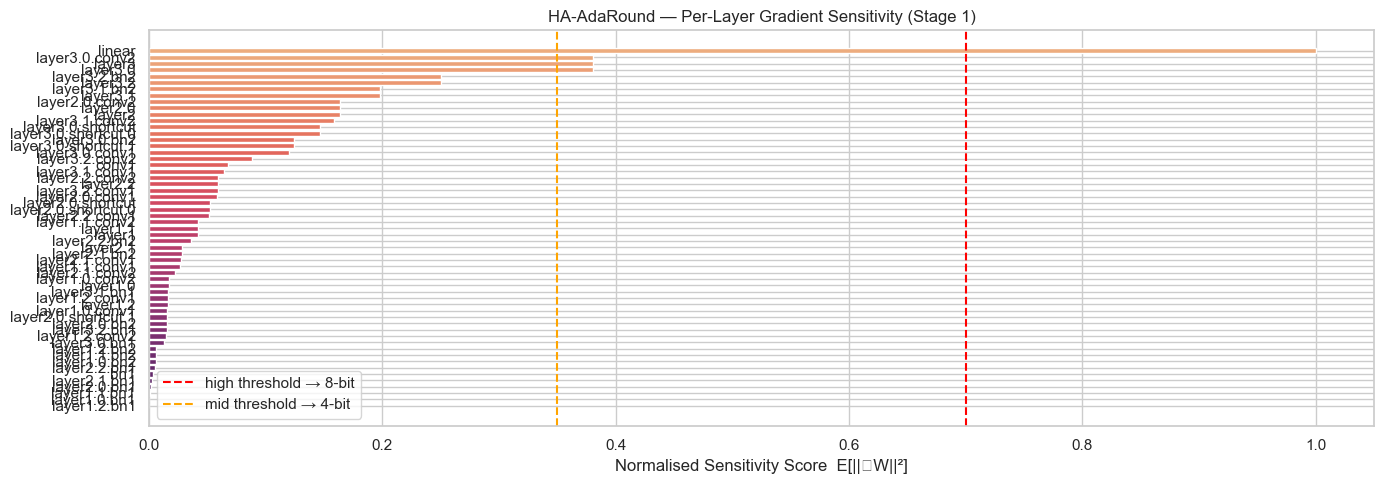

In [7]:
layer_scores = load_json("layer_sensitivity.json")

if layer_scores:
    df_sens = (
        pd.DataFrame(list(layer_scores.items()), columns=["layer", "sensitivity"])
        .query("sensitivity > 0")
        .sort_values("sensitivity", ascending=False)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.barh(df_sens["layer"][::-1], df_sens["sensitivity"][::-1],
                   color=sns.color_palette("flare", len(df_sens))[::-1])
    ax.axvline(0.70, color="red",    linestyle="--", lw=1.5, label="high threshold → 8-bit")
    ax.axvline(0.35, color="orange", linestyle="--", lw=1.5, label="mid threshold → 4-bit")
    ax.set_xlabel("Normalised Sensitivity Score  E[||∇W||²]")
    ax.set_title("HA-AdaRound — Per-Layer Gradient Sensitivity (Stage 1)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 2. Bit-Width Distribution

Inspect the mixed-precision allocation produced by the allocator (Stage 2).

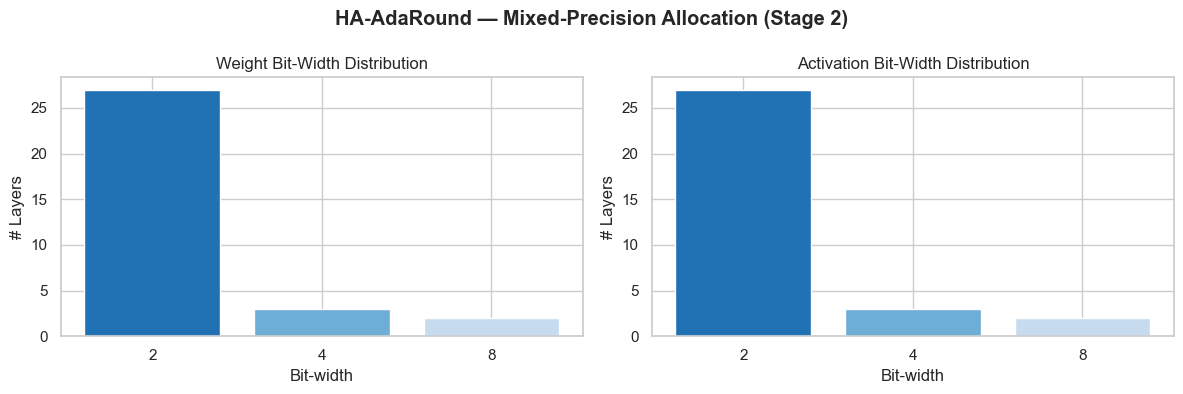

         layer  weight_bits  act_bits
         conv1            8         8
        layer1            2         2
      layer1.0            2         2
layer1.0.conv1            2         2
layer1.0.conv2            2         2
      layer1.1            2         2
layer1.1.conv1            2         2
layer1.1.conv2            2         2
      layer1.2            2         2
layer1.2.conv1            2         2
layer1.2.conv2            2         2
        layer2            2         2
      layer2.0            2         2
layer2.0.conv1            2         2
layer2.0.conv2            2         2
      layer2.1            2         2
layer2.1.conv1            2         2
layer2.1.conv2            2         2
      layer2.2            2         2
layer2.2.conv1            2         2
layer2.2.conv2            2         2
        layer3            4         4
      layer3.0            4         4
layer3.0.conv1            2         2
layer3.0.conv2            4         4
      layer3

In [8]:
quant_config = load_json("quant_config.json")

if quant_config:
    # quant_config schema (post-AdaRound):
    # { "layer_name": { "name": "integer", "weight_width": N,
    #                   "data_in_width": N, "bias_width": N, ... } }
    df_bits = pd.DataFrame(
        [
            {
                "layer": k,
                "weight_bits": v.get("weight_width", 8),
                "act_bits":    v.get("data_in_width", 8),
            }
            for k, v in quant_config.items()
            if isinstance(v, dict) and v.get("name") == "integer"
        ]
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, col, title in zip(
        axes,
        ["weight_bits", "act_bits"],
        ["Weight Bit-Width Distribution", "Activation Bit-Width Distribution"],
    ):
        counts = df_bits[col].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values,
               color=sns.color_palette("Blues_r", len(counts)))
        ax.set_xlabel("Bit-width")
        ax.set_ylabel("# Layers")
        ax.set_title(title)

    plt.suptitle("HA-AdaRound — Mixed-Precision Allocation (Stage 2)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(df_bits[["layer", "weight_bits", "act_bits"]].to_string(index=False))

## 3. Model Compression Analysis

Estimate the memory footprint reduction achieved by mixed-precision allocation  
compared to a full fp32 (32-bit) baseline.  
Computed directly from `quant_config.json` — no additional output files needed.

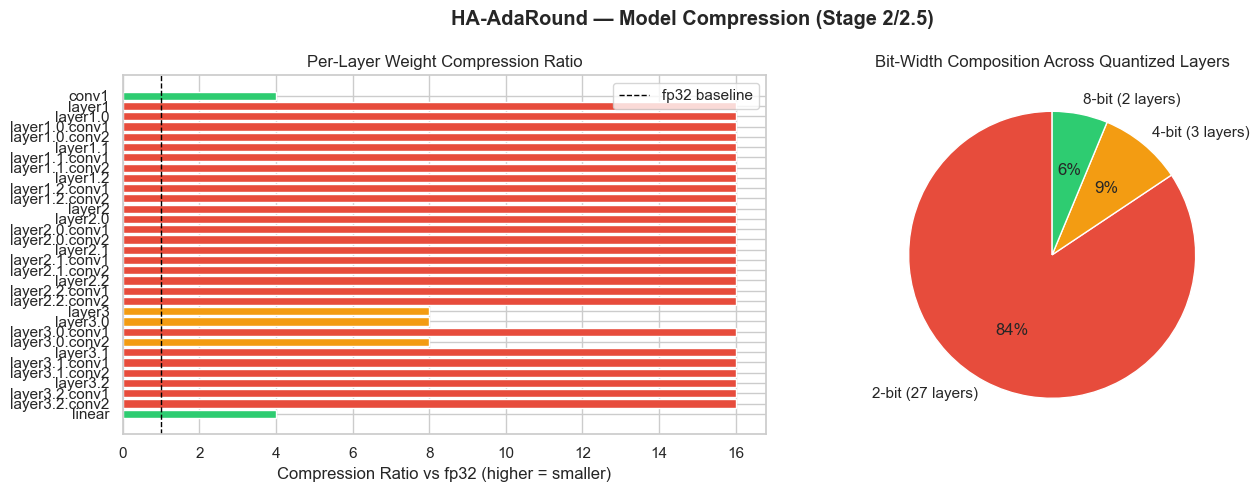

Quantized layers  : 32
Average bit-width : 2.56 bits  (fp32 = 32)
Average compression ratio : 14.5x vs fp32


In [9]:
if quant_config:
    FP32_BITS = 32
    rows = []
    for layer, cfg in quant_config.items():
        if not isinstance(cfg, dict) or cfg.get("name") != "integer":
            continue
        w_bits = cfg.get("weight_width", 8)
        rows.append({
            "layer": layer,
            "weight_bits": w_bits,
            # compression ratio for this layer's weights vs fp32
            "compression_ratio": FP32_BITS / w_bits,
            # bit saving per weight element
            "bits_saved": FP32_BITS - w_bits,
        })

    df_comp = pd.DataFrame(rows)

    if not df_comp.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Left: per-layer compression ratio ---
        palette = {2: "#e74c3c", 4: "#f39c12", 8: "#2ecc71"}
        colors = df_comp["weight_bits"].map(palette).fillna("grey")
        axes[0].barh(df_comp["layer"][::-1], df_comp["compression_ratio"][::-1],
                     color=colors[::-1])
        axes[0].axvline(1.0, color="black", linestyle="--", lw=1, label="fp32 baseline")
        axes[0].set_xlabel("Compression Ratio vs fp32 (higher = smaller)")
        axes[0].set_title("Per-Layer Weight Compression Ratio")
        axes[0].legend()

        # --- Right: pie of bit-width composition across all layers ---
        bit_counts = df_comp["weight_bits"].value_counts().sort_index()
        axes[1].pie(
            bit_counts.values,
            labels=[f"{b}-bit ({n} layers)" for b, n in bit_counts.items()],
            colors=[palette.get(b, "grey") for b in bit_counts.index],
            autopct="%1.0f%%",
            startangle=90,
        )
        axes[1].set_title("Bit-Width Composition Across Quantized Layers")

        plt.suptitle("HA-AdaRound — Model Compression (Stage 2/2.5)", fontweight="bold")
        plt.tight_layout()
        plt.show()

        # Summary stats
        avg_ratio = df_comp["compression_ratio"].mean()
        avg_bits  = df_comp["weight_bits"].mean()
        print(f"Quantized layers  : {len(df_comp)}")
        print(f"Average bit-width : {avg_bits:.2f} bits  (fp32 = 32)")
        print(f"Average compression ratio : {avg_ratio:.1f}x vs fp32")

## 4. Baseline vs. Quantized Accuracy Comparison

Compares fp32 baseline accuracy against the HA-AdaRound mixed-precision model.  
Requires `eval_baseline.json` and `eval_quantized.json` from the evaluator.

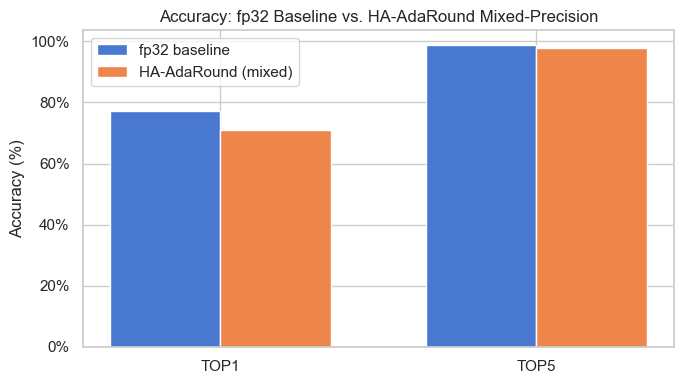

TOP1: baseline=77.18%  quantized=70.86%  drop=+6.32%
TOP5: baseline=98.69%  quantized=97.91%  drop=+0.78%


In [14]:
baseline  = load_json("eval_baseline.json").get("metrics", {})
quantized = load_json("eval_quantized.json").get("metrics", {})

if baseline and quantized:
    metrics = [k for k in baseline if k.startswith("top")]
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - width/2, [baseline[m]  for m in metrics], width, label="fp32 baseline")
    ax.bar(x + width/2, [quantized[m] for m in metrics], width, label="HA-AdaRound (mixed)")
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics])
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy: fp32 Baseline vs. HA-AdaRound Mixed-Precision")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()
    plt.tight_layout()
    plt.show()

    for m in metrics:
        drop = baseline[m] - quantized[m]
        print(f"{m.upper()}: baseline={baseline[m]:.2f}%  quantized={quantized[m]:.2f}%  drop={drop:+.2f}%")
else:
    print("Run the Evaluator to generate eval_baseline.json / eval_quantized.json first.")

## 5. Sensitivity Score vs. Assigned Bit-Width

Validates that the allocator policy is consistent with the profiler output.  
Each point is one layer — colour encodes its assigned bit-width.

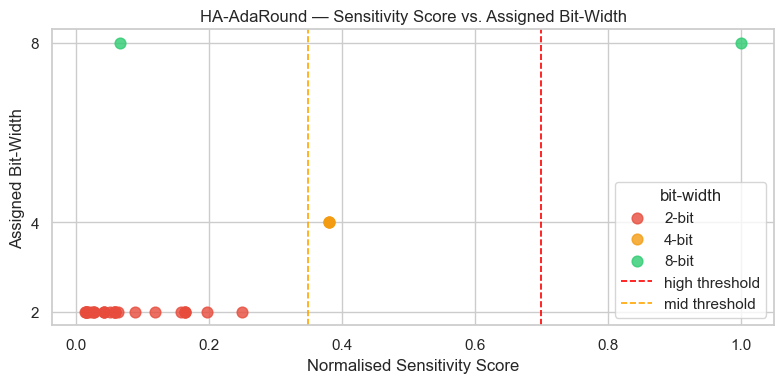

In [11]:
if layer_scores and quant_config:
    rows = []
    for layer, score in layer_scores.items():
        cfg = quant_config.get(layer, {})
        if isinstance(cfg, dict) and cfg.get("name") == "integer":
            rows.append({
                "layer": layer,
                "sensitivity": score,
                "weight_bits": cfg.get("weight_width", 8),
            })

    df_scatter = pd.DataFrame(rows)

    if not df_scatter.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        palette = {2: "#e74c3c", 4: "#f39c12", 8: "#2ecc71"}
        for bits, grp in df_scatter.groupby("weight_bits"):
            ax.scatter(grp["sensitivity"], [bits] * len(grp),
                       color=palette.get(bits, "grey"), label=f"{bits}-bit",
                       s=60, alpha=0.8)
        ax.axvline(0.70, color="red",    linestyle="--", lw=1.2, label="high threshold")
        ax.axvline(0.35, color="orange", linestyle="--", lw=1.2, label="mid threshold")
        ax.set_yticks([2, 4, 8])
        ax.set_xlabel("Normalised Sensitivity Score")
        ax.set_ylabel("Assigned Bit-Width")
        ax.set_title("HA-AdaRound — Sensitivity Score vs. Assigned Bit-Width")
        ax.legend(title="bit-width")
        plt.tight_layout()
        plt.show()